Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
 
plt.style.use("seaborn-v0_8")

Paths

In [ ]:
BASE       = Path(r"C:\Users\jorge gonzalez\Documents\TFG\Proyecto")
DATA_PATH  = BASE / "data" / "processed" / "livvo_day_hotel_final.parquet"
OUTPUT_DIR = BASE / "notebooks" / "00_exploracion" / "peak_analysis" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Cargar hotel 3

In [3]:
df = pd.read_parquet(DATA_PATH)
df = df[df["codigo_hotel"] == "HOTEL_3"].copy()
 
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
 
print("Rango datos:", df["date"].min(), "→", df["date"].max())
df.head()

Rango datos: 2023-01-01 00:00:00 → 2025-12-23 00:00:00


,date,codigo_hotel,roomnights,bednights,neto,stock,ocup_total,ADR
0,2023-01-01,HOTEL_3,154,328,41940.92,251,0.613546,272.343636
1,2023-01-02,HOTEL_3,164,347,41479.70,251,0.653386,252.925000
2,2023-01-03,HOTEL_3,159,335,25886.08,251,0.633466,162.805535
3,2023-01-04,HOTEL_3,153,313,23733.26,251,0.609562,155.119346
4,2023-01-05,HOTEL_3,170,345,25345.60,251,0.677291,149.091765


Serie temporal

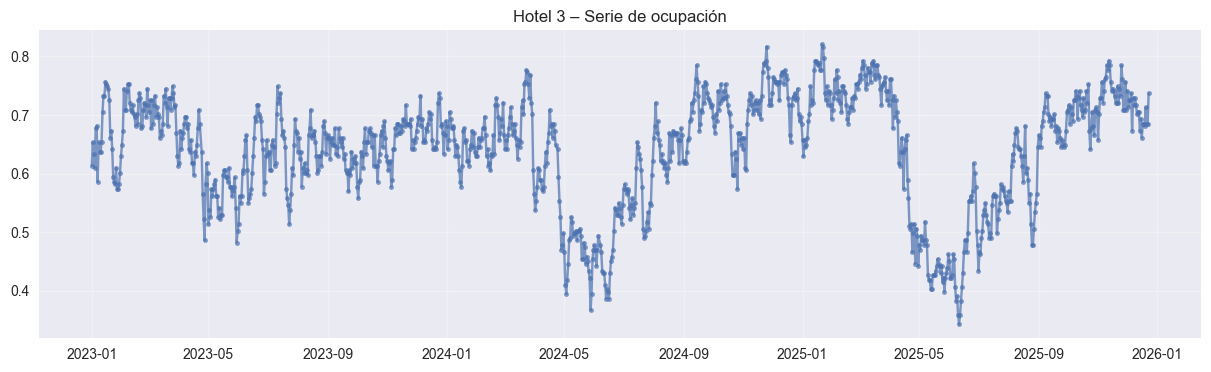

In [4]:
plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["ocup_total"], marker=".", alpha=0.7)
plt.title("Hotel 3 – Serie de ocupación")
plt.grid(alpha=0.3)
plt.show()

Descomposición estacional

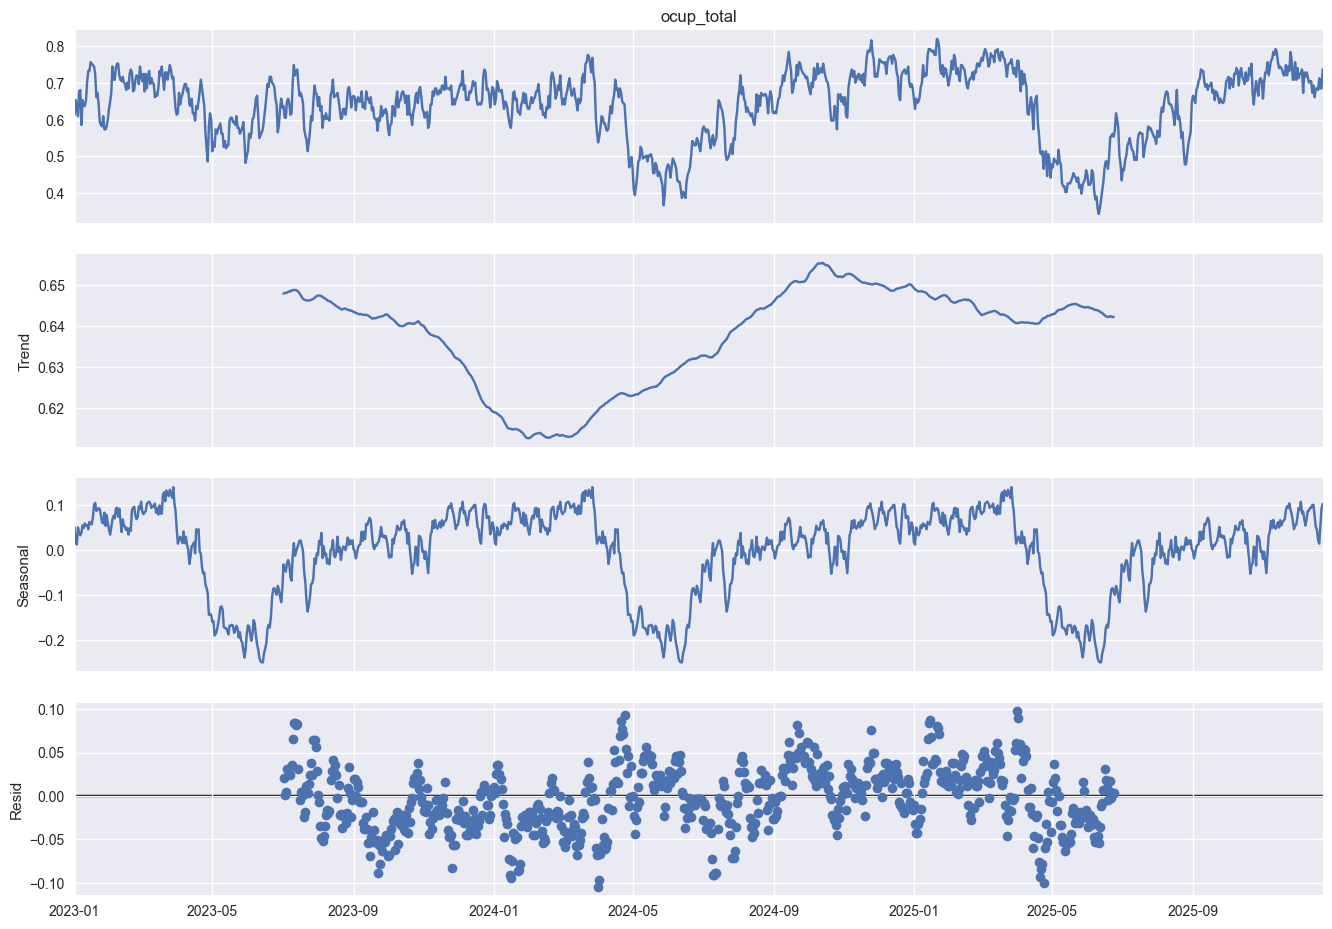

In [5]:
serie  = df.set_index("date")["ocup_total"].asfreq("D").interpolate()
decomp = seasonal_decompose(serie, model="additive", period=365)
fig    = decomp.plot()
fig.set_size_inches(14, 10)
plt.show()

Curvas YOY

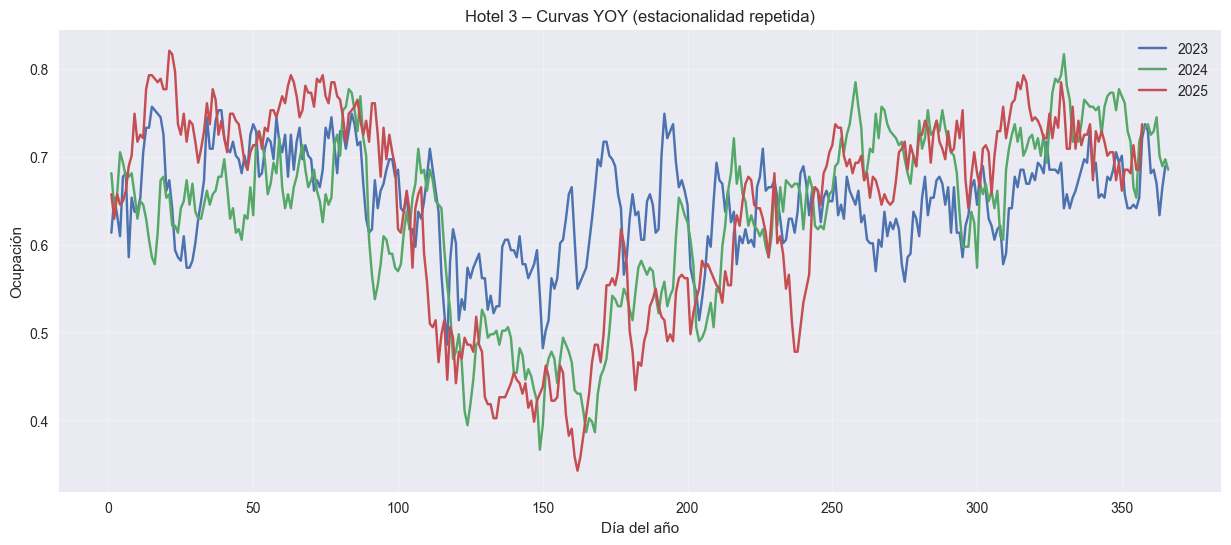

In [6]:
df["year"]      = df["date"].dt.year
df["dayofyear"] = df["date"].dt.dayofyear
 
plt.figure(figsize=(15, 6))
for y in sorted(df["year"].unique()):
    plt.plot(df[df["year"] == y]["dayofyear"],
             df[df["year"] == y]["ocup_total"],
             label=str(y))
 
plt.title("Hotel 3 – Curvas YOY (estacionalidad repetida)")
plt.xlabel("Día del año")
plt.ylabel("Ocupación")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Suavizado por año

In [7]:
df["ocup_smooth"] = (
    df["ocup_total"]
    .rolling(30, center=True, min_periods=1)
    .mean()
)
df["year"] = df["date"].dt.year

Procesar cada año individualmente

In [8]:
all_segments  = []
annual_points = []
 
for year in sorted(df["year"].unique()):
 
    year_df = df[df["year"] == year].copy()
    year_df["trend"] = year_df["ocup_smooth"].diff(7)
 
    threshold_up   = year_df["trend"].quantile(0.75)
    threshold_down = year_df["trend"].quantile(0.25)
 
    def classify_regime(x):
        if x >= threshold_up:
            return "UP"
        elif x <= threshold_down:
            return "DOWN"
        return "FLAT"
 
    year_df["regime"]     = year_df["trend"].apply(classify_regime)
    year_df["segment_id"] = (year_df["regime"] != year_df["regime"].shift()).cumsum()
 
    segments = year_df.groupby("segment_id").agg(
        start    = ("date", "min"),
        end      = ("date", "max"),
        regime   = ("regime", "first"),
        mean_occ = ("ocup_total", "mean"),
        max_occ  = ("ocup_total", "max"),
        min_occ  = ("ocup_total", "min"),
        duration = ("date", "count")
    ).reset_index()
 
    segments = segments[
        (segments["duration"] >= 12) &
        (segments["regime"].isin(["UP", "DOWN"]))
    ]
 
    segments["year"]     = year
    segments["mid_date"] = segments["start"] + (segments["end"] - segments["start"]) / 2
 
    def classify_season_type(regime):
        if regime == "UP":
            return "PEAK_BUILDUP"
        elif regime == "DOWN":
            return "VALLEY_DROP"
        return "MID"
 
    segments["season_type"] = segments["regime"].apply(classify_season_type)
    all_segments.append(segments)
 
    max_row = year_df.loc[year_df["ocup_smooth"].idxmax()]
    annual_points.append({
        "year": year, "point_type": "MAX",
        "point_date": max_row["date"], "point_occ": max_row["ocup_smooth"]
    })
 
    min_row = year_df.loc[year_df["ocup_smooth"].idxmin()]
    annual_points.append({
        "year": year, "point_type": "MIN",
        "point_date": min_row["date"], "point_occ": min_row["ocup_smooth"]
    })

Consolidar Outputs

In [9]:
segments_final = pd.concat(all_segments, ignore_index=True)
points_final   = pd.DataFrame(annual_points)
 
segments_final["point_type"] = None
segments_final["point_date"] = pd.NaT
segments_final["point_occ"]  = np.nan
 
for i, seg in segments_final.iterrows():
    year_points = points_final[points_final["year"] == seg["year"]]
    for _, p in year_points.iterrows():
        if seg["start"] <= p["point_date"] <= seg["end"]:
            segments_final.loc[i, "point_type"] = p["point_type"]
            segments_final.loc[i, "point_date"] = p["point_date"]
            segments_final.loc[i, "point_occ"]  = p["point_occ"]

Export

In [10]:
output_path = OUTPUT_DIR / "peak_Hotel3.parquet"
segments_final.to_parquet(output_path, index=False)
print(f"✅ Guardado en: {output_path}")
print("\nPreview:")
print(segments_final.head())

✅ Guardado en: C:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\notebooks\00_exploracion\peak_analysis\outputs\peak_Hotel3.parquet

Preview:
   segment_id      start        end regime  mean_occ   max_occ   min_occ  \
0          10 2023-02-09 2023-02-20     UP  0.709163  0.737052  0.681275   
1          18 2023-04-01 2023-05-12   DOWN  0.612768  0.709163  0.486056   
2          22 2023-06-04 2023-06-23     UP  0.634263  0.717131  0.549801   
3           6 2024-03-20 2024-03-31   DOWN  0.717131  0.776892  0.565737   
4           8 2024-04-09 2024-05-18   DOWN  0.550822  0.709163  0.394422   

   duration  year            mid_date   season_type point_type point_date  \
0        12  2023 2023-02-14 12:00:00  PEAK_BUILDUP        MAX 2023-02-18   
1        41  2023 2023-04-21 12:00:00   VALLEY_DROP       None        NaT   
2        20  2023 2023-06-13 12:00:00  PEAK_BUILDUP       None        NaT   
3        12  2024 2024-03-25 12:00:00   VALLEY_DROP       None        NaT   
4        39  

Visualización

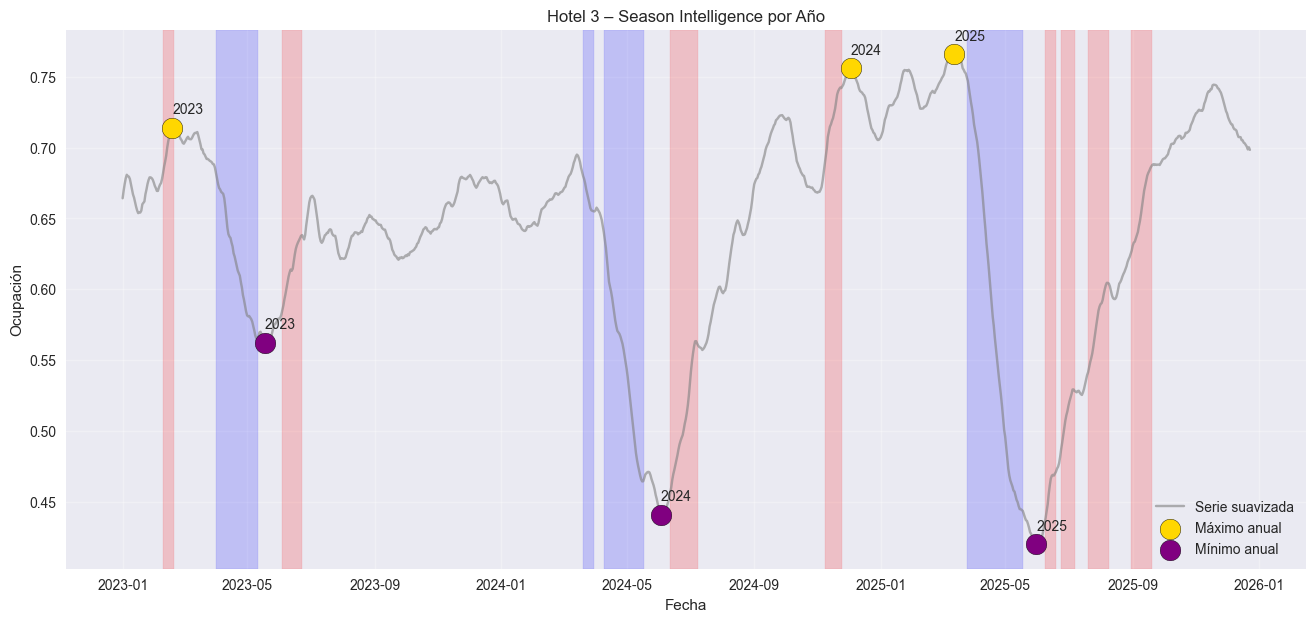

In [11]:
plt.figure(figsize=(16, 7))
 
plt.plot(df["date"], df["ocup_smooth"],
         color="gray", alpha=0.6, label="Serie suavizada")
 
for _, r in segments_final.iterrows():
    color = "red" if r["regime"] == "UP" else "blue"
    plt.axvspan(r["start"], r["end"], color=color, alpha=0.18)
 
max_points = points_final[points_final["point_type"] == "MAX"]
plt.scatter(max_points["point_date"], max_points["point_occ"],
            color="gold", s=220, edgecolor="black",
            label="Máximo anual", zorder=5)
 
min_points = points_final[points_final["point_type"] == "MIN"]
plt.scatter(min_points["point_date"], min_points["point_occ"],
            color="purple", s=220, edgecolor="black",
            label="Mínimo anual", zorder=5)
 
for _, r in points_final.iterrows():
    plt.text(r["point_date"], r["point_occ"] + 0.01, str(r["year"]), fontsize=10)
 
plt.title("Hotel 3 – Season Intelligence por Año")
plt.xlabel("Fecha")
plt.ylabel("Ocupación")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# CONCLUSIÓN FINAL – SEASON INTELLIGENCE DEL HOTEL 3 (VACACIONAL / MIXTO)

En este análisis se ha desarrollado un sistema de **Season Intelligence** aplicado al Hotel 3, cuyo comportamiento se sitúa en un punto intermedio entre un hotel puramente vacacional como el Hotel 2 y un hotel urbano orientado a eventos como el Hotel 1.

La demanda del Hotel 3 no depende principalmente de eventos puntuales externos, pero tampoco presenta una estacionalidad tan rígida y predecible como el Hotel 2. En su lugar, muestra una combinación de:

- patrones estacionales recurrentes
- fases de recuperación progresiva
- mayor variabilidad interanual

Por ello, el análisis se ha rediseñado para detectar de forma más precisa:

- periodos de crecimiento acelerado (**PEAK BUILDUP**)
- periodos de caída estructural (**VALLEY DROP**)
- máximos anuales de ocupación
- mínimos anuales de ocupación

Todo ello segmentado por año para facilitar una integración coherente con el dashboard y su filtrado temporal.

---

# Enfoque metodológico aplicado

El análisis sigue una lógica adaptada al comportamiento híbrido del Hotel 3:

1. Análisis exploratorio de la serie histórica de ocupación.
2. Descomposición de tendencia y patrones estacionales.
3. Análisis Year-over-Year (YOY) para identificar recurrencia temporal.
4. Suavizado de la serie para reducir ruido diario.
5. Cálculo de pendientes semanales para detectar movimientos estructurales.
6. Segmentación anual en periodos de subida pronunciada (**UP**) y bajada pronunciada (**DOWN**).
7. Identificación de máximos anuales.
8. Identificación de mínimos anuales.
9. Exportación consolidada en parquet para visualización en dashboard.

Este enfoque permite analizar dinámicas estructurales sin sobredimensionar picos aislados de corta duración.

---

# Interpretación de resultados

## 1. El Hotel 3 presenta una estacionalidad clara, pero más variable que el Hotel 2

Los datos muestran patrones repetitivos, pero con mayor variabilidad entre años:

- existen temporadas altas recurrentes
- existen caídas estacionales claras
- pero la intensidad de los movimientos cambia más entre ejercicios

Esto sugiere que el Hotel 3 combina demanda vacacional estructural con una mayor sensibilidad a factores complementarios.

---

## 2. El máximo anual de 2023 aparece de forma temprana

El máximo anual detectado se produce en:

### 2023
**18 de febrero de 2023**
Ocupación suavizada máxima: **71.4%**

Esto indica que el Hotel 3 alcanza uno de sus mejores momentos comerciales muy temprano en el año, antes de entrar en una fase posterior de ajuste.

---

## 3. Las caídas estructurales son más prolongadas que en el Hotel 2

### 2023
Se observa una caída importante entre abril y mayo.

### 2024
Se detecta una caída prolongada entre marzo y mayo, con una reducción significativa de ocupación.

### 2025
Aparece la caída más extensa del análisis, entre marzo y mayo, con una duración de **55 días**, reflejando una fase de ajuste mucho más larga que en años anteriores.

Esto evidencia una mayor volatilidad operativa frente al comportamiento más estable del Hotel 2.

---

## 4. El Hotel 3 muestra múltiples fases de recuperación

Uno de los elementos más diferenciales del hotel es que las recuperaciones aparecen en varias fases consecutivas:

### 2023
- recuperación en junio

### 2024
- recuperación en verano
- nuevo impulso en el último trimestre

### 2025
- recuperación en junio
- nueva recuperación en julio
- nueva recuperación en agosto
- nuevo impulso en septiembre

Esto sugiere que la demanda del Hotel 3 se reconstruye de forma más gradual y fragmentada que en el Hotel 2.

---

# Conclusiones del análisis

## 1. El Hotel 3 presenta un comportamiento híbrido

El hotel combina:

- estacionalidad vacacional estructural
- mayor volatilidad interanual
- fases de recuperación más fragmentadas

## 2. La segmentación anual mejora significativamente la interpretación

Separar cada ejercicio permite visualizar correctamente fases de crecimiento, fases de caída, y máximos y mínimos anuales sin mezclar dinámicas de distintos años.

## 3. El Hotel 3 requiere una gestión más dinámica que el Hotel 2

La mayor fragmentación en las recuperaciones sugiere que pricing, revenue management y planificación operativa deben ser más flexibles que en un hotel puramente vacacional.

## 4. La metodología representa mejor el comportamiento real

El análisis basado en tramos estructurales de subida y bajada ofrece una visión mucho más útil que un enfoque basado únicamente en forecast.

---

# Conclusión global

El Hotel 3 presenta un perfil **vacacional/mixto**, con patrones estacionales claros pero con mayor volatilidad y capacidad de recuperación fragmentada que el Hotel 2.

La metodología de *Season Intelligence* permite identificar con mayor precisión:

- ciclos anuales de demanda
- fases de caída estructural
- múltiples fases de recuperación
- máximos y mínimos relevantes

Generando una herramienta mucho más útil para dashboard y para la toma de decisiones comerciales basadas exclusivamente en comportamiento histórico real.